In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("All libraries loaded!!")

All libraries loaded!!


In [7]:
df = pd.read_csv('../data/SuperStoreOrders.csv')

df.columns = df.columns.str.replace('ï»¿', '', regex=False).str.strip()

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (51290, 21)

Columns: ['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']

Missing values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

Data types:
order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region   

In [9]:
df['sales']      = pd.to_numeric(df['sales'], errors='coerce')
df['profit']     = pd.to_numeric(df['profit'], errors='coerce')
df['discount']   = pd.to_numeric(df['discount'], errors='coerce')
df['quantity']   = pd.to_numeric(df['quantity'], errors='coerce')
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=False)

before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")

df = df[df['sales'] > 0]
df = df[df['quantity'] > 0]

df['unit_price'] = df['sales'] / df['quantity']
df['profit_margin'] = (df['profit']/df['sales']) * 100
df['revenue_lost'] = df['sales'] * df['discount']

print(f"\nFinal shape: {df.shape}")
print(df[['sales','quantity','discount','profit','unit_price','profit_margin']].describe().round(2))


Duplicates removed: 0

Final shape: (48659, 24)
          sales  quantity  discount    profit  unit_price  profit_margin
count  48659.00  48659.00  48659.00  48659.00    48659.00       48659.00
mean     161.02      3.35      0.15     14.69       56.24           4.19
std      201.09      2.20      0.22     86.83       76.92          47.47
min        1.00      1.00      0.00  -1924.54        0.25        -472.78
25%       29.00      2.00      0.00      0.00       11.25           0.00
50%       77.00      3.00      0.00      8.46       27.00          16.85
75%      208.00      4.00      0.20     31.16       65.50          33.45
max      999.00     14.00      0.85    486.60      925.00          58.28


In [10]:
loss = df[df['profit'] < 0]

print(f"Total orders      : {len(df)}")
print(f"Loss-making orders: {len(loss)}  ({len(loss)/len(df)*100:.1f}%)")
print(f"\nLoss by category:")
print(loss.groupby('category')['profit'].sum().round(2).sort_values())
print(f"\nLoss by region:")
print(loss.groupby('region')['profit'].sum().round(2).sort_values())

Total orders      : 48659
Loss-making orders: 12107  (24.9%)

Loss by category:
category
Furniture         -273860.70
Office Supplies   -219276.85
Technology        -217551.56
Name: profit, dtype: float64

Loss by region:
region
Central          -148092.83
South            -118542.68
EMEA             -103054.75
Africa            -85602.72
Southeast Asia    -69292.51
North             -42382.97
Oceania           -41230.36
East              -26656.80
Caribbean         -22331.87
Central Asia      -19066.72
North Asia        -17573.51
West              -16861.42
Name: profit, dtype: float64


In [11]:
cat_summary = df.groupby('category').agg(
    total_sales = ('sales',          'sum'),
    total_profit = ('profit',        'sum'),
    avg_discount = ('discount',      'mean'),
    avg_margin   = ('profit_margin', 'mean'),
    num_orders   = ('sales',         'count')
).round(2)

print(cat_summary)

                 total_sales  total_profit  avg_discount  avg_margin  \
category                                                               
Furniture          2406605.0      97049.38          0.17       -0.12   
Office Supplies    2790258.0     350108.43          0.14        5.70   
Technology         2638265.0     267573.47          0.14        3.33   

                 num_orders  
category                     
Furniture              8906  
Office Supplies       30735  
Technology             9018  


In [12]:
subcat = df.groupby('sub_category').agg(
    total_sales = ('sales',          'sum'),
    total_profit = ('profit',        'sum'),
    avg_discount = ('discount',      'mean'),
    avg_margin   = ('profit_margin', 'mean'),
    num_orders   = ('sales',         'count')
).sort_values('avg_margin').round(2)

print(subcat.to_string())

              total_sales  total_profit  avg_discount  avg_margin  num_orders
sub_category                                                                 
Tables           289686.0     -69921.27          0.33      -33.74         607
Machines         414983.0      22674.96          0.18       -6.62        1302
Appliances       377590.0      29703.96          0.16       -3.93        1426
Bookcases        811505.0      53580.69          0.17       -1.26        2031
Binders          346130.0      48538.12          0.18       -0.33        6108
Storage          913499.0      74684.47          0.14        0.80        4903
Chairs           927982.0      68377.74          0.17        1.55        3105
Phones           870518.0      78170.21          0.15        2.70        2950
Copiers          782710.0      85220.45          0.13        3.92        1810
Supplies         210069.0      23994.55          0.13        4.41        2417
Furnishings      377432.0      45012.22          0.15        5.4

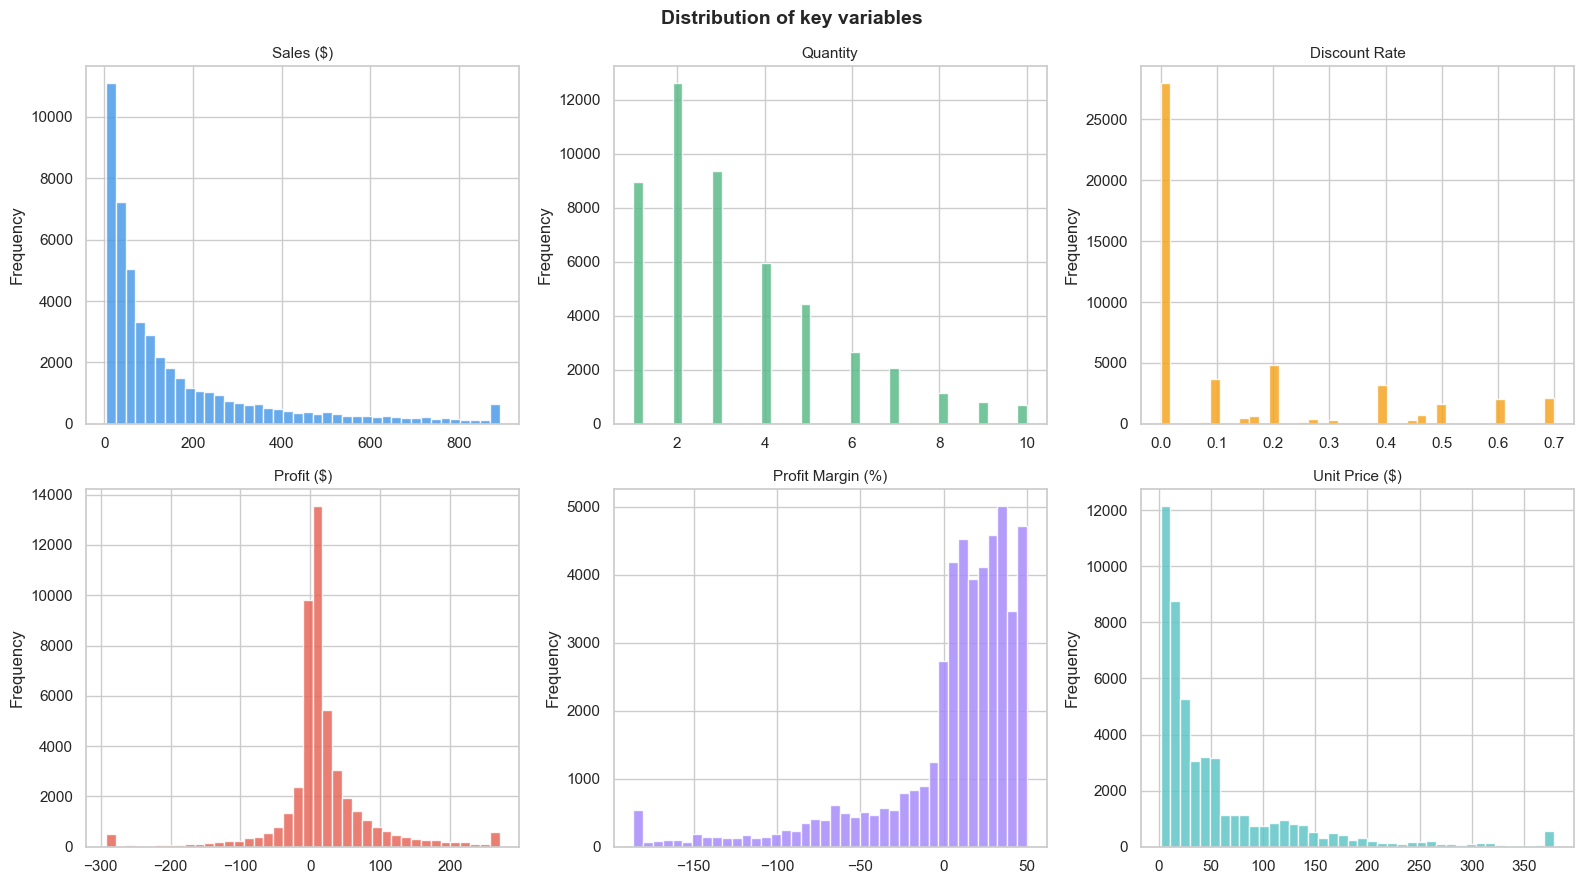

..Saved..


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
fig.suptitle('Distribution of key variables', fontsize=14, fontweight='bold')

plot_cols = ['sales', 'quantity', 'discount', 'profit', 'profit_margin', 'unit_price']
colors    = ['#4C9BE8', '#5DBB8A', '#F5A623', '#E8675A', '#A78BFA', '#60C6C6']
labels    = ['Sales ($)', 'Quantity', 'Discount Rate', 'Profit ($)', 'Profit Margin (%)', 'Unit Price ($)']

for ax, col, color, label in zip(axes.flatten(), plot_cols, colors, labels):
    data = df[col].dropna()
    lower,upper = data.quantile(0.01), data.quantile(0.99)
    ax.hist(data.clip(lower, upper), bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("..Saved..")

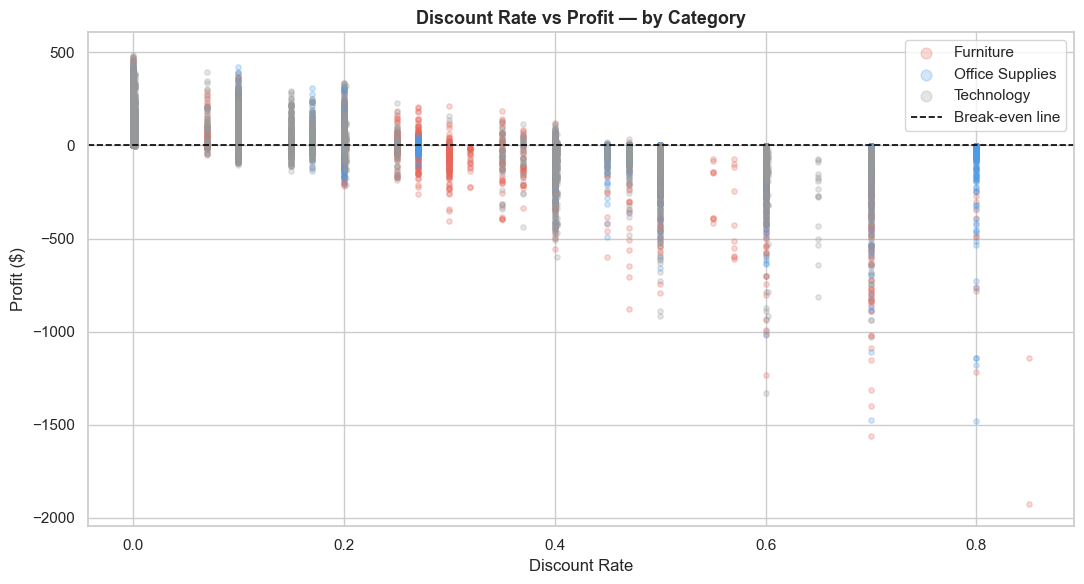

Saved ✓


In [14]:
fig, ax = plt.subplots(figsize=(11,6))

colors_cat = {
    'Furniture':       '#E8675A',
    'Office Supplies': '#4C9BE8',
    'Technlogy':       '#5DBB8A',
}

for cat, grp in df.groupby('category'):
    ax.scatter(grp['discount'], grp['profit'],
               alpha=0.25, s=15, label=cat,
               color=colors_cat.get(cat, '#999'))

ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='Break-even line')
ax.set_xlabel('Discount Rate', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.set_title('Discount Rate vs Profit — by Category', fontsize=13, fontweight='bold')
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig('../outputs/01_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

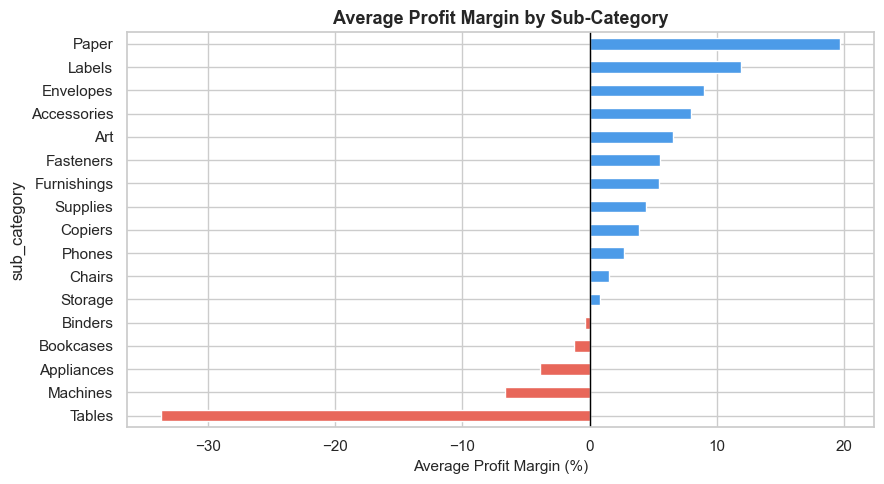

Saved ✓


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

subcat_plot = df.groupby('sub_category')['profit_margin'].mean().sort_values()
colors_bar  = ['#E8675A' if v < 0 else '#4C9BE8' for v in subcat_plot]

subcat_plot.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Average Profit Margin (%)', fontsize=11)
ax.set_title('Average Profit Margin by Sub-Category', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/01_subcat_margins.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")